In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from astropy.visualization import simple_norm

import glob
from PIL import Image
import os
from IPython import display

from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
import matplotlib.patches as patches


%matplotlib inline

In [2]:
# load fits data 
# import moment maps
directory = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848/"
# original cube 

data_cube = fits.getdata(directory + "S0116+4114_HIcube2_clean_smooth_image_4_cube.fits")
data_header =fits.getheader(directory + "S0116+4114_HIcube2_clean_smooth_image_4_cube.fits")
mask_cube_smooth = fits.getdata(directory + "S0116+4114_HIcube2_clean_smooth_image_4_mask.fits")


In [3]:
# optical images
header_optical = fits.getheader(directory + "S0116-4114-sdssg-optical.fits")  
data_optical = fits.getdata(directory + "S0116-4114-sdssg-optical.fits")

In [4]:
print(data_optical.shape)

(300, 300)


In [5]:
# ctype 3 is in frequency, we need to convert it to velocity
# we can use the formula: v = c * (f - f0) / f0
# where c is the speed of light, f is the frequency, and f0 is the rest frequency of the HI line (1420.40575 MHz)

c = 299792.458 # speed of light in km/s
f0 = 1420.40575 # rest frequency of the HI line in MHz
f = data_header['CRVAL3'] + np.arange(data_header['NAXIS3']) * data_header['CDELT3'] # frequency array in HZ
f =f / 1e6 # convert frequency to MHz
v = c * (f - f0) / f0 # velocity array in km/s

In [6]:
# Apply the mask to the data cube

masked_data_smooth=np.where(mask_cube_smooth,data_cube,0)

In [7]:
# Compute the moment 0 map (integrated intensity) of the data cube
mom0_dat_smooth = np.nansum(masked_data_smooth,axis=0) * (v[1] - v[0]) # km/s

In [8]:
# overlay the HI moment 0 map on the optical image
wcs_header = WCS(data_header).celestial
wcs_optical = WCS(header_optical).celestial

hi_reprojected_0, footprint = reproject_interp((mom0_dat_smooth, wcs_header), wcs_optical)
rms_mom0 = np.sqrt(np.nanmean(hi_reprojected_0**2))

hi_levels = np.linspace(rms_mom0, np.nanmax(hi_reprojected_0), 10)

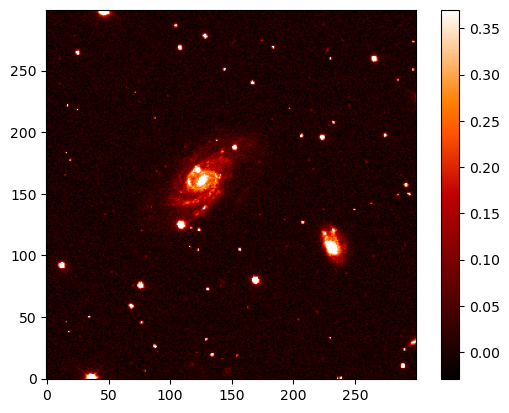

In [9]:
vmin, vmax = np.percentile(data_optical, [1, 99.5])
plt.imshow(data_optical, cmap='gist_heat', vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar()
plt.show()

/tmp/ipykernel_6258/2756923807.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


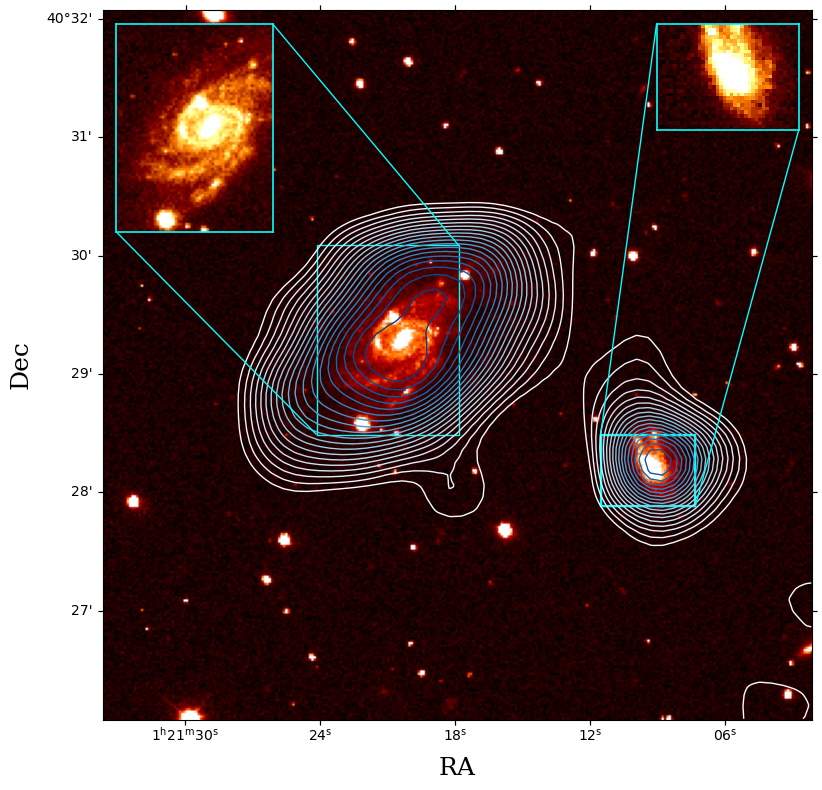

In [10]:

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(1, 1, 1, projection=WCS(header_optical))

# Background: Optical image
cb = ax.imshow(
    data_optical,
    cmap='gist_heat',  
    origin='lower',
    vmin=vmin, vmax=vmax,
)


levels = np.linspace(0.5 * rms_mom0, np.nanmax(hi_reprojected_0), 20)
ax.contour(
    hi_reprojected_0,
    levels=levels,
    cmap='Blues', 
    linewidths=1,
)

x1, x2 = 210, 250   # pixel columns
y1, y2 = 90, 120   # pixel rows

# Rectangle on the main image (in pixel coords)
rect = patches.Rectangle(
    (x1, y1), x2 - x1, y2 - y1,
    transform=ax.get_transform('pixel'),
    fill=False, lw=1.6, edgecolor='cyan'
)
ax.add_patch(rect)

# Create inset 
zoom = 1.5  # change magnification as needed
axins = zoomed_inset_axes(ax, zoom=zoom, loc="upper right", borderpad=1.0)
axins.imshow(data_optical, cmap='afmhot', vmin=vmin, vmax=vmax, origin='lower')
axins.set_xlim(210, 250) # x1, x2
axins.set_ylim(90, 120) # y1, y2
# Clean inset look
axins.set_xticks([])
axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_edgecolor('cyan')
    spine.set_linewidth(1.2)

zoom = 1.1  # change magnification as needed
axins1 = zoomed_inset_axes(ax, zoom=zoom, loc="upper left", borderpad=1.0)
axins1.imshow(data_optical, cmap='afmhot', vmin=vmin, vmax=vmax, origin='lower')
axins1.set_xlim(90, 150) # x1, x2
axins1.set_ylim(120, 200) # y1, y2

# Clean inset look
axins1.set_xticks([])
axins1.set_yticks([])
for spine in axins1.spines.values():
    spine.set_edgecolor('cyan')
    spine.set_linewidth(1.2)

# Connector lines between rectangle and inset
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="cyan", lw=1.0)
mark_inset(ax, axins1, loc1=1, loc2=3, fc="none", ec="cyan", lw=1.0)

ax.set_xlabel('RA', size=18, family='serif')
ax.set_ylabel('Dec', size=18, family='serif')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)


plt.tight_layout()
plt.show()

In [11]:
print(np.nanmax(hi_reprojected_0),np.nanmin(hi_reprojected_0))


1.4092750768485025 -0.22666489889676103


/tmp/ipykernel_6258/1426541860.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


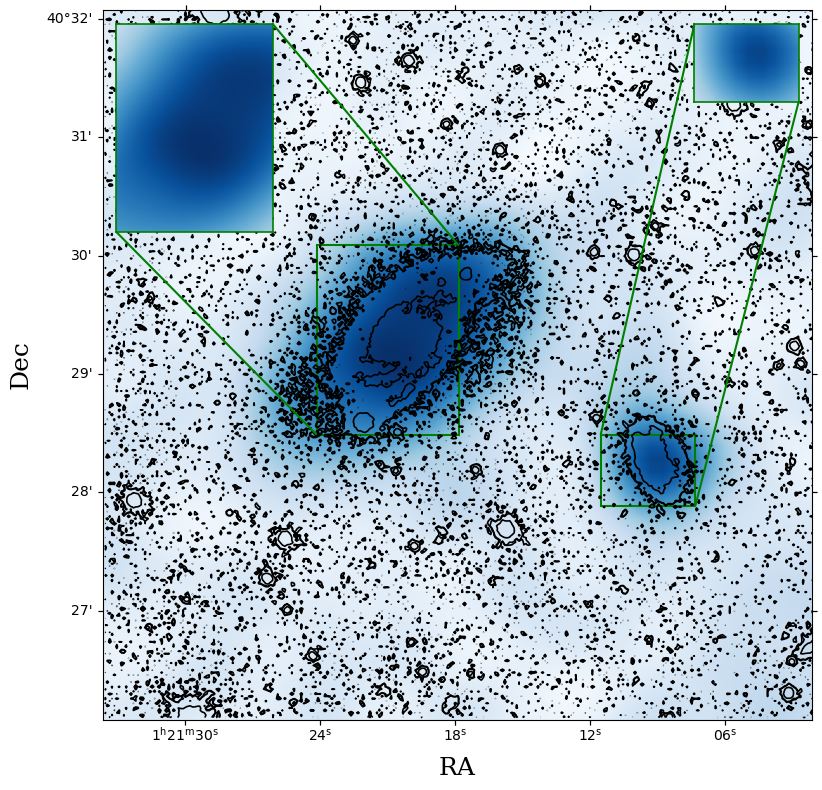

In [12]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(1, 1, 1, projection=WCS(header_optical))

# Background: HI moment 0 map (Blues)
im_hi = ax.imshow(
    hi_reprojected_0,
    cmap='Blues',
    origin='lower',
    alpha=1,
    vmin=np.nanmin(hi_reprojected_0),
    vmax=np.nanmax(hi_reprojected_0)
)

# Overlay: optical image (Oranges), semi-transparent
#im_opt = ax.imshow(
#    data_optical,
#    cmap='gist_heat',
#    origin='lower',
#    alpha=0.5,
#    vmin=vmin,
#    vmax=vmax
#)

# Optical contours (optional, for more effect)
contour_levels = np.percentile(data_optical, [80, 90, 98])
ax.contour(
    data_optical,
    levels=contour_levels,
    colors='black',
    linewidths=1.2,
    origin='lower'
)

#x1, x2 = 0, 30   # pixel columns
#y1, y2 = 0, 30   # pixel rows
# Rectangle and insets (unchanged)
#rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, transform=ax.get_transform('pixel'),
#                         fill=False, lw=1.6, edgecolor='cyan')
#ax.add_patch(rect)

zoom = 1.1
axins = zoomed_inset_axes(ax, zoom=zoom, loc="upper right", borderpad=1.0)
axins.imshow(hi_reprojected_0, cmap='Blues', origin='lower')
axins.set_xlim(210, 250)
axins.set_ylim(90, 120)
axins.set_xticks([])
axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_edgecolor('green')
    spine.set_linewidth(1.2)

axins1 = zoomed_inset_axes(ax, zoom=zoom, loc="upper left", borderpad=1.0)
axins1.imshow(hi_reprojected_0, cmap='Blues', origin='lower')
axins1.set_xlim(90, 150)
axins1.set_ylim(120, 200)
axins1.set_xticks([])
axins1.set_yticks([])
for spine in axins1.spines.values():
    spine.set_edgecolor('green')
    spine.set_linewidth(1.2)



mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="green", lw=1.5)
mark_inset(ax, axins1, loc1=1, loc2=3, fc="none", ec="green", lw=1.5)


ax.set_xlabel('RA', size=18, family='serif')
ax.set_ylabel('Dec', size=18, family='serif')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig("arp86_hi_optical_overlay.png", dpi=300)
plt.tight_layout()
plt.show()

In [13]:
print(np.nanmax(hi_reprojected_0))
print(np.nanmin(hi_reprojected_0))

1.4092750768485025
-0.22666489889676103


/tmp/ipykernel_6258/1756655880.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


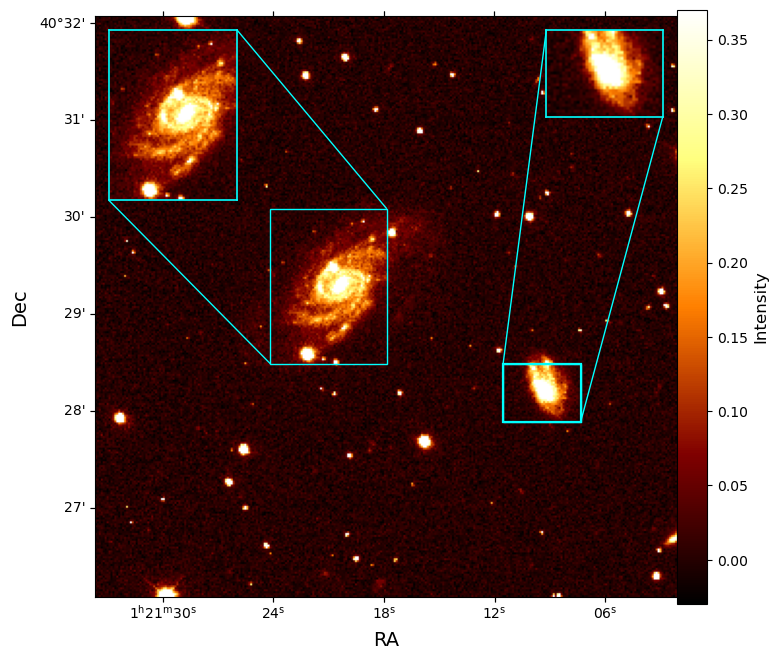

In [14]:
wcs = WCS(header_optical)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection=wcs)

# Main image
im = ax.imshow(data_optical, cmap='afmhot', vmin=vmin, vmax=vmax, origin='lower')

ax.set_xlabel('RA', fontsize=14)
ax.set_ylabel('Dec', fontsize=14)

# Colorbar: same height, right next to image
cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.952, pad=0.001)
cbar.set_label('Intensity', fontsize=12)

# --------- ZOOMED INSET (PIXEL COORDS) ---------
# Choose your pixel ROI (columns = x, rows = y). Update these numbers:
x1, x2 = 210, 250   # pixel columns
y1, y2 = 90, 120   # pixel rows

# Rectangle on the main image (in pixel coords)
rect = patches.Rectangle(
    (x1, y1), x2 - x1, y2 - y1,
    transform=ax.get_transform('pixel'),
    fill=False, lw=1.6, edgecolor='cyan'
)
ax.add_patch(rect)

# Create inset 
zoom = 1.5  # change magnification as needed
axins = zoomed_inset_axes(ax, zoom=zoom, loc="upper right", borderpad=1.0)
axins.imshow(data_optical, cmap='afmhot', vmin=vmin, vmax=vmax, origin='lower')
axins.set_xlim(210, 250) # x1, x2
axins.set_ylim(90, 120) # y1, y2
# Clean inset look
axins.set_xticks([])
axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_edgecolor('cyan')
    spine.set_linewidth(1.2)

zoom = 1.1  # change magnification as needed
axins1 = zoomed_inset_axes(ax, zoom=zoom, loc="upper left", borderpad=1.0)
axins1.imshow(data_optical, cmap='afmhot', vmin=vmin, vmax=vmax, origin='lower')
axins1.set_xlim(90, 150) # x1, x2
axins1.set_ylim(120, 200) # y1, y2

# Clean inset look
axins1.set_xticks([])
axins1.set_yticks([])
for spine in axins1.spines.values():
    spine.set_edgecolor('cyan')
    spine.set_linewidth(1.2)

# Connector lines between rectangle and inset
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="cyan", lw=1.0)
mark_inset(ax, axins1, loc1=1, loc2=3, fc="none", ec="cyan", lw=1.0)

plt.tight_layout()
plt.savefig("ngc7753-optical-inset.png", dpi=300)
plt.show()

In [15]:
# moment 0 of the system 
data_mom0_ngc7753 = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC477/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9mod_0mom_azim.fits")
data_mom0_ngc7753_obs = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC477/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_0mom.fits")

In [16]:
data_mom0_ngc7753_obs=np.where(np.isnan(data_mom0_ngc7753_obs),0,data_mom0_ngc7753_obs)

In [17]:

# ngc477
#data moment1
data_mom1_ngc477 = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC477/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9mod_1mom_azim.fits")
header_mom1_ngc477 = fits.getheader("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC477/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9mod_1mom_azim.fits")
data_mom1_ngc477_obs = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC477/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_1mom.fits")

#main galaxy
#data moment1
data_mom1_main= fits.getdata(directory+"/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9mod_1mom_azim.fits")
data_mom1_main_obs = fits.getdata(directory+"/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_1mom.fits")

# second galaxy
data_mom1_second = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848-2Galaxy/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9mod_1mom_azim.fits")
data_mom1_second_obs = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848-2Galaxy/output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_1mom.fits")

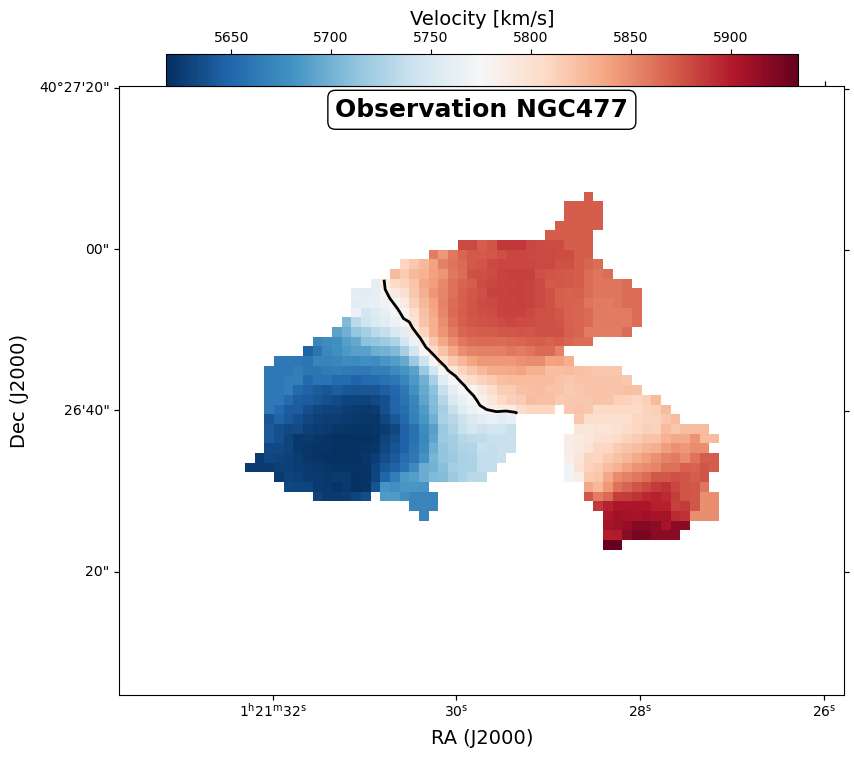

In [18]:
plt.figure(figsize=(9, 8))
ax = plt.subplot(111, projection=WCS(header_optical))  # Use WCS for correct RA/Dec

# Moment 1 map (velocity field)
im = ax.imshow(data_mom1_ngc477_obs, cmap='RdBu_r', origin='lower')

# add the systemic velocity contour 
# Add systemic velocity contour (separating red/blue)
systemic_velocity = 5770  # km/s - adjust this value for NGC477's systemic velocity
ax.contour(data_mom1_ngc477_obs, levels=[systemic_velocity], colors='black', linewidths=2, origin='lower')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', location='top', shrink=0.83, pad=0.001)
cbar.set_label('Velocity [km/s]', fontsize=14)

# Add label box
ax.text(0.5, 0.95, 'Observation NGC477', fontsize=18, weight='bold', color='black',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round', pad=0.3),
        transform=ax.transAxes, ha='center')

ax.set_xlabel('RA (J2000)', fontsize=14)
ax.set_ylabel('Dec (J2000)', fontsize=14)
plt.tight_layout()
#plt.savefig("ngc477_mom1_obs.png", dpi=300)
plt.show()

/tmp/ipykernel_6258/526125089.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


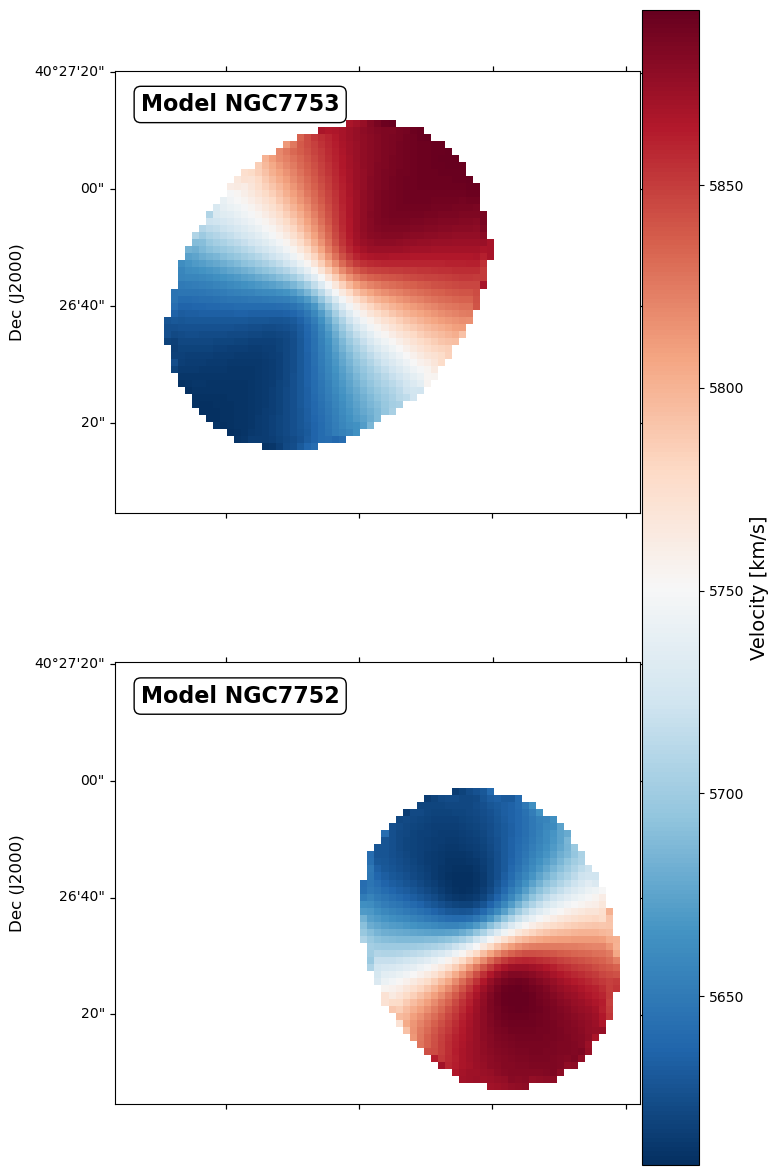

In [19]:
fig = plt.figure(figsize=(8, 15))

# Create subplots with minimal spacing
gs = fig.add_gridspec(2, 1, hspace=0.05)

# Panel 1: NGC7753
ax1 = fig.add_subplot(gs[0, 0], projection=WCS(header_optical))
im1 = ax1.imshow(data_mom1_main, cmap='RdBu_r', origin='lower')
ax1.text(0.05, 0.95, 'Model NGC7753', fontsize=16, weight='bold', color='black',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round',pad=0.3),
        transform=ax1.transAxes, ha='left', va='top')
ax1.set_ylabel('Dec (J2000)', fontsize=12)
ax1.tick_params(axis='x', labelsize=10, labelbottom=False)  # Hide x-tick labels
ax1.set_xticks([])  # Remove x-ticks completely

# Panel 2: NGC7752
ax2 = fig.add_subplot(gs[1, 0], projection=WCS(header_optical))
im2 = ax2.imshow(data_mom1_second, cmap='RdBu_r', origin='lower')
ax2.text(0.05, 0.95, 'Model NGC7752', fontsize=16, weight='bold', color='black',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round',pad=0.3),
        transform=ax2.transAxes, ha='left', va='top')
ax2.set_ylabel('Dec (J2000)', fontsize=12)
ax2.tick_params(axis='x', labelsize=10, labelbottom=False)  # Hide x-tick labels
ax2.set_xticks([])  # Remove x-ticks completely


# Single colorbar on the right for all three panels
cbar = fig.colorbar(im1, ax=[ax1, ax2], location='right', shrink=1, pad=0.002)
cbar.set_label('Velocity [km/s]', fontsize=14)

plt.tight_layout()
plt.savefig("arp86_mom1_models.png", dpi=300, bbox_inches='tight')
plt.show()

### Residual

In [20]:
 # data cube of each galaxy
galaxy1 = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848/output/SoFiA_J012118.02+402905.9/SoFiA_J012118.02+402905.9mod_azim.fits")

galaxy2 = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848-2Galaxy/output/SoFiA_J012118.02+402905.9/SoFiA_J012118.02+402905.9mod_azim.fits")

In [36]:
def calc_rms(x):
    rms = np.sqrt(np.mean(x**2))
    return rms

rmsgal1 = calc_rms(galaxy1)
rmsgal2 = calc_rms(galaxy2)
print(rmsgal1)
print(rmsgal2)

0.0009654228
0.00042064063


In [50]:

# Mask the cube, to only retain signal that is above 5 times the rms
mask5_cube = np.where(data_cube < 3*calc_rms(data_cube), 0, data_cube)
masked_gal1 = np.where(galaxy1 < 3*rmsgal1, 0, galaxy1)
masked_gal2 = np.where(galaxy2 < 3*rmsgal2, 0, galaxy2)


In [51]:
# create the residual 
data_residual = mask5_cube - (masked_gal1+masked_gal2)
#data_residual = np.where(mask_cube_smooth,data_residual,0)

In [52]:
#data_residual_masked = np.where(mask_cube_smooth,data_residual,0)

In [53]:
mom0_dat_residual = np.nansum(data_residual,axis=0)*abs(data_header['CDELT3'])/1000
mom0_dat_residual = np.where(mom0_dat_residual<0,0,mom0_dat_residual)

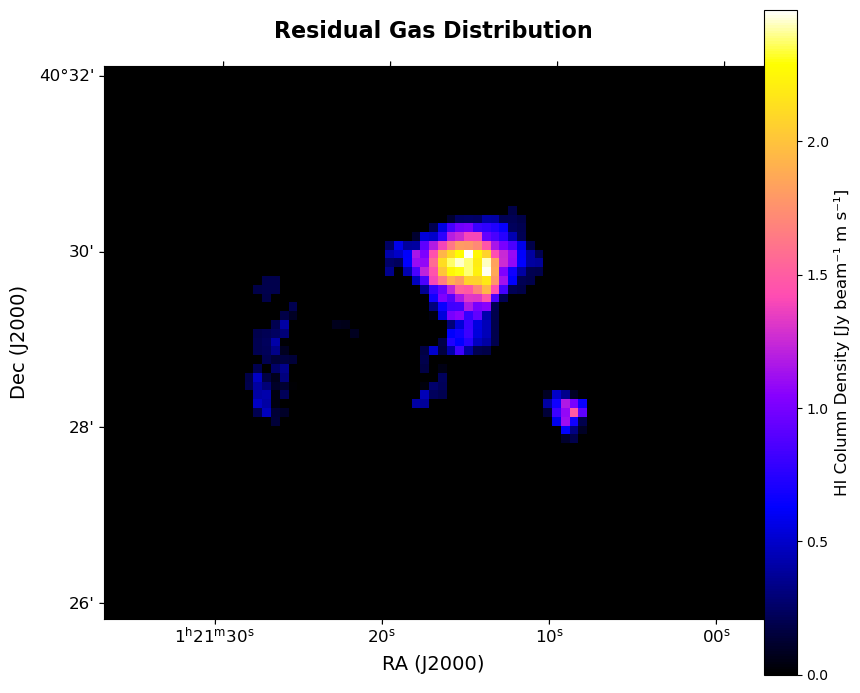

In [54]:
# Create figure with WCS projection
fig = plt.figure(figsize=(9, 8))
ax = plt.subplot(111, projection=WCS(header_mom1_ngc477))

# Display residual moment 0 map
im = ax.imshow(mom0_dat_residual, cmap='gnuplot2', origin='lower')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, location='right', shrink=0.93, pad=0.001)
cbar.set_label('HI Column Density [Jy beam⁻¹ m s⁻¹]', fontsize=12)

# Set proper axis labels with WCS
ax.set_xlabel('RA (J2000)', fontsize=14)
ax.set_ylabel('Dec (J2000)', fontsize=14)
ax.tick_params(labelsize=12)

# Add title
ax.set_title('Residual Gas Distribution', fontsize=16, weight='bold', pad=20)

# Improve layout
plt.tight_layout()
plt.savefig("residual_gas_mom0.png", dpi=300, bbox_inches='tight')
plt.show()

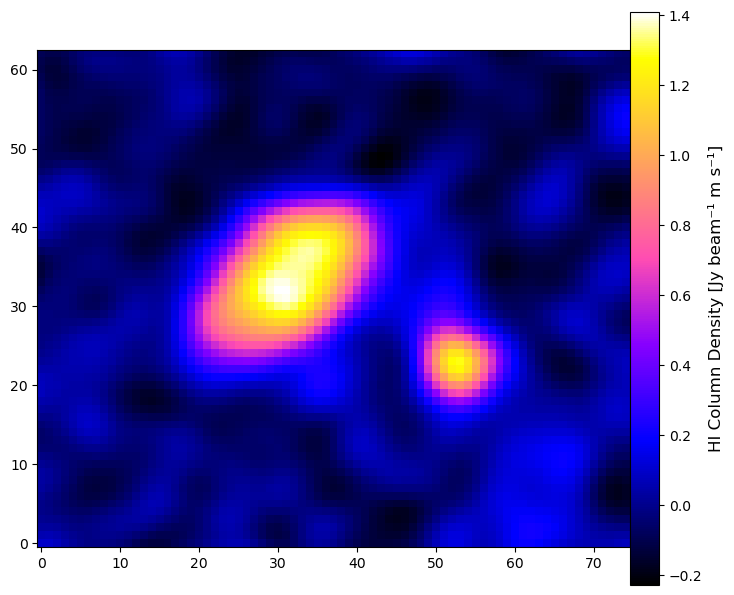

In [49]:
plt.figure(figsize=(9,8))
ax =plt.subplot(111)
im=ax.imshow(mom0_dat_smooth,cmap="gnuplot2", origin="lower")
# Add colorbar
cbar = plt.colorbar(im, ax=ax, location='right', shrink=0.93, pad=0.001)
cbar.set_label('HI Column Density [Jy beam⁻¹ m s⁻¹]', fontsize=12)
plt.show()